In [14]:
#Link : https://www.mdpi.com/2218-1997/10/12/449

In [15]:
import numpy as np
from scipy.integrate import quad
import scipy.constants as const
import matplotlib.pyplot as plt

In [16]:
k = 4 * 22 * 4.301 * 0.01992e9 / (7 * const.c**2)  # G = 4.301e-6
L = 50
#Integrand
def int(x, l):
    r0 = 8.5
    rh = 11.41
    n = 0.43
    x0 = r0 / l
    r = l * (x0**2 - 2 * x * x0 * np.cos(np.radians(280)) * np.cos(np.radians(-33)) + x**2)**(1/2)
    rho =  np.exp(- (r / rh)**(1/n))
    return rho * x * (1-x) 

In [17]:
l_val = np.arange(0.5, 50, 0.5)


int_val = []
int_val1 = []

for t in l_val:
    l = t
    res, er = quad(int, 0, 1, args=(l)) 
    result = k * l**2 * res
    int_val.append(result)
    int_val1.append(l)
    



int_val = np.array(int_val)
int_val1 = np.array(int_val1)

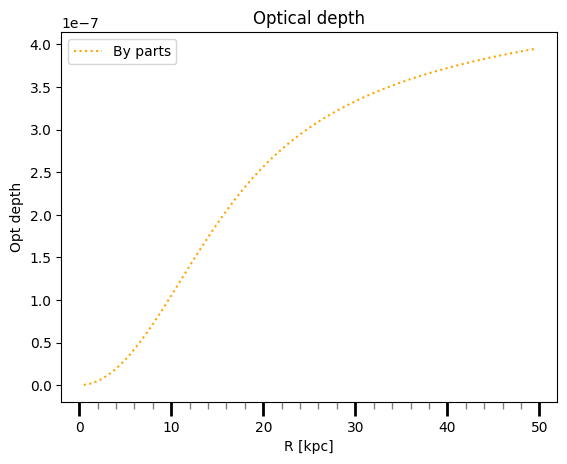

In [18]:
# Create the plot
fig, ax = plt.subplots()

# Plot the data
ax.plot(l_val, int_val, label = 'By parts', color = 'orange', linestyle = ':')
#ax.plot(l_value, int_val1, label = 'Direct', color = 'green', linestyle = '--')

# Set major ticks locator and format
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(2))
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

# Customize the ticks
ax.tick_params(axis='x', which='major', length=10, width=2)
ax.tick_params(axis='x', which='minor', length=5, width=1, color='gray')

# Set labels
ax.set_xlabel('R [kpc]')
ax.set_ylabel('Opt depth')
ax.set_title('Optical depth')

# Show the grid
ax.grid(False, which='both')
plt.legend()

# Display the plot
plt.show()

In [19]:
'''

import numpy as np
import matplotlib.pyplot as plt

# Function for r
def r_function(l, x, x0):
    return l * np.sqrt(x0**2 - 2 * x * x0 * np.cos(np.radians(280)) * np.cos(np.radians(-33)) + x**2)

# Function for the integrand
def integrand(x, l, x0, rh, n):
    r = r_function(l, x, x0)
    return (l**2) * x * (1 - x) * np.exp(- (r / rh)**(1/n))

# Monte Carlo integration function
def monte_carlo_integrate(func, l, x0, n, rh, num_samples=100000):
    x_samples = np.random.uniform(0, 1, num_samples)  # Samples of x in the range [0, 1]
    
    # Calculate integral using Monte Carlo method
    integral_values = np.zeros(num_samples)
    for i in range(num_samples):
        x = x_samples[i]
        integral_values[i] = func(x, l, x0, rh, n)
    
    # Mean of the integrand times the width of the integration range (1 - 0)
    return np.mean(integral_values)

# Parameters
rh = 11.41
n = 0.43

# Loop over l values and perform the integration
l_values = np.arange(0.5, 50.5, 0.5)  # l from 0.5 to 50 with a step of 0.5
results = []

# Perform Monte Carlo integration for each value of l
for l in l_values:
    x0 = 8.5 / l  # x0 is given as 8.5 / l
    integral = monte_carlo_integrate(integrand, l, x0, n, rh)
    results.append((l, integral))

# Unzip results into two lists
l_vals, integrals = zip(*results)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(l_vals, integrals, marker='o', linestyle='-', color='b')
plt.title('Monte Carlo Integration Results', fontsize=14)
plt.xlabel('l', fontsize=12)
plt.ylabel('Integral', fontsize=12)
plt.grid(True)
plt.show()

'''

"\n\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Function for r\ndef r_function(l, x, x0):\n    return l * np.sqrt(x0**2 - 2 * x * x0 * np.cos(np.radians(280)) * np.cos(np.radians(-33)) + x**2)\n\n# Function for the integrand\ndef integrand(x, l, x0, rh, n):\n    r = r_function(l, x, x0)\n    return (l**2) * x * (1 - x) * np.exp(- (r / rh)**(1/n))\n\n# Monte Carlo integration function\ndef monte_carlo_integrate(func, l, x0, n, rh, num_samples=100000):\n    x_samples = np.random.uniform(0, 1, num_samples)  # Samples of x in the range [0, 1]\n    \n    # Calculate integral using Monte Carlo method\n    integral_values = np.zeros(num_samples)\n    for i in range(num_samples):\n        x = x_samples[i]\n        integral_values[i] = func(x, l, x0, rh, n)\n    \n    # Mean of the integrand times the width of the integration range (1 - 0)\n    return np.mean(integral_values)\n\n# Parameters\nrh = 11.41\nn = 0.43\n\n# Loop over l values and perform the integration\nl_values = np.a